<a href="https://colab.research.google.com/github/malak-mahdaoui/Transformer/blob/main/Transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pywt
import numpy as np
import matplotlib.pyplot as plt
import cv2


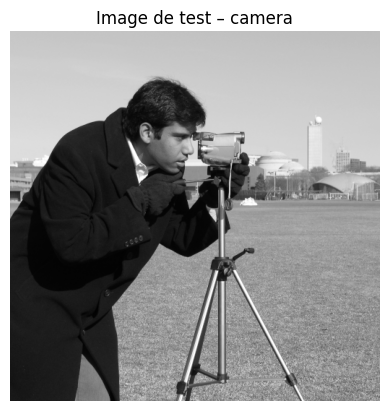

In [ ]:
from skimage import data
import matplotlib.pyplot as plt
import numpy as np

# Charger image "camera" standard
img = data.camera()  # 512x512 pixels, grayscale

plt.imshow(img, cmap='gray')
plt.title("Image de test – camera")
plt.axis('off')
plt.show()


In [ ]:
if img is None:

    img = np.zeros((256, 256), dtype=np.float32)
    cv2.rectangle(img, (60, 60), (200, 200), 255, -1)
else:
    img = img.astype(np.float32)

if img.ndim != 2:
    raise ValueError("L'image doit être 2D (grayscale)")

In [ ]:
coeffs = pywt.wavedec2(img, wavelet='haar', level=5)


In [ ]:
max_level = pywt.dwt_max_level(min(img.shape), 'haar')
print("Max level:", max_level)


Max level: 9


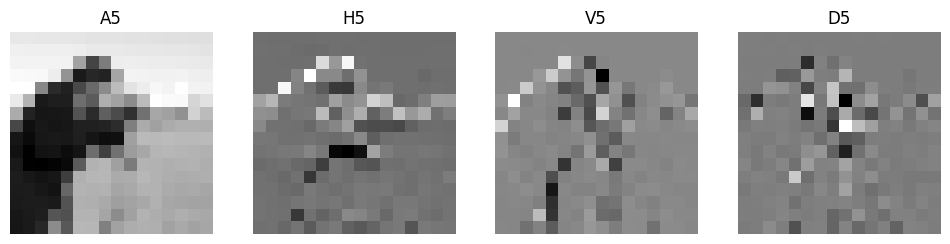

In [ ]:
# 5 a) Affichage coefficients (A,H,V,D) par niveau

A5 = coeffs[0]
H5, V5, D5 = coeffs[1]

plt.figure(figsize=(12,4))
plt.subplot(1,4,1); plt.imshow(A5, cmap='gray'); plt.title('A5'); plt.axis('off')
plt.subplot(1,4,2); plt.imshow(H5, cmap='gray'); plt.title('H5'); plt.axis('off')
plt.subplot(1,4,3); plt.imshow(V5, cmap='gray'); plt.title('V5'); plt.axis('off')
plt.subplot(1,4,4); plt.imshow(D5, cmap='gray'); plt.title('D5'); plt.axis('off')
plt.show()

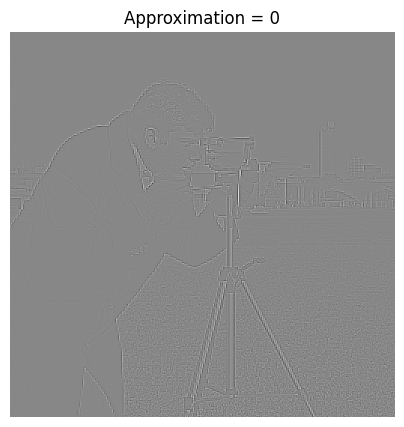

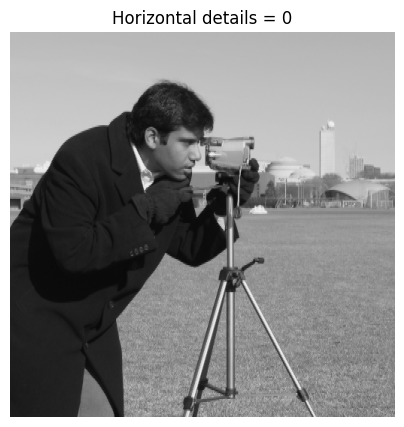

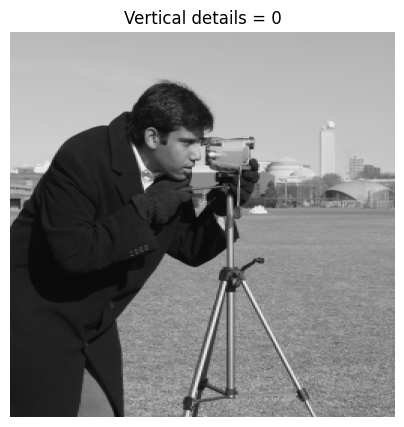

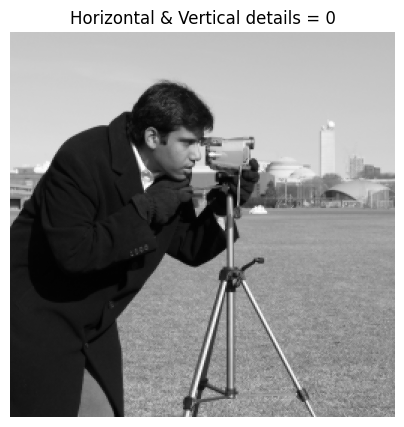

array([[199, 199, 199, ..., 189, 189, 189],
       [199, 199, 199, ..., 189, 189, 189],
       [199, 199, 198, ..., 189, 189, 189],
       ...,
       [ 24,  24,  24, ..., 155, 143, 147],
       [ 24,  24,  24, ..., 150, 144, 159],
       [ 24,  24,  24, ..., 144, 159, 144]], dtype=uint8)
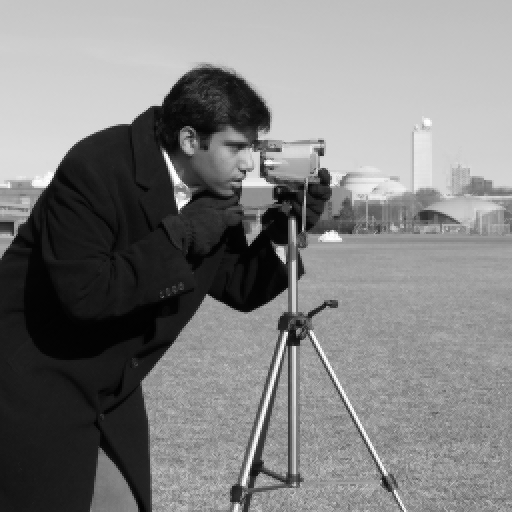

In [ ]:
def plot_reconstruction(coeffs_modified, original_shape, title):
    # Reconstruction
    img_rec = pywt.waverec2(coeffs_modified, 'haar')

    # Ajuster la taille à l'original
    img_rec = img_rec[:original_shape[0], :original_shape[1]]

    # Normalisation
    img_rec = img_rec - np.min(img_rec)
    if np.max(img_rec) != 0:
        img_rec = img_rec / np.max(img_rec)
    img_rec = (img_rec * 255).astype(np.uint8)

    # Affichage
    plt.figure(figsize=(5,5))
    plt.imshow(img_rec, cmap='gray', vmin=0, vmax=255)
    plt.title(title)
    plt.axis('off')
    plt.show()

    return img_rec

# -----------------------------
# 4️⃣ b) Approximation = 0
# -----------------------------
coeffs_A0 = list(coeffs)
coeffs_A0[0] = np.zeros_like(coeffs_A0[0])
plot_reconstruction(coeffs_A0, img.shape, "Approximation = 0")

# -----------------------------
# 5️⃣ c) Horizontal details = 0
# -----------------------------
coeffs_H0 = [coeffs[0]]
for (H,V,D) in coeffs[1:]:
    coeffs_H0.append((np.zeros_like(H), V, D))
plot_reconstruction(coeffs_H0, img.shape, "Horizontal details = 0")

# -----------------------------
# 6️⃣ d) Vertical details = 0
# -----------------------------
coeffs_V0 = [coeffs[0]]
for (H,V,D) in coeffs[1:]:
    coeffs_V0.append((H, np.zeros_like(V), D))
plot_reconstruction(coeffs_V0, img.shape, "Vertical details = 0")

# -----------------------------
# 7️⃣ e) Horizontal & Vertical details = 0
# -----------------------------
coeffs_HV0 = [coeffs[0]]
for (H,V,D) in coeffs[1:]:
    coeffs_HV0.append((np.zeros_like(H), np.zeros_like(V), D))
plot_reconstruction(coeffs_HV0, img.shape, "Horizontal & Vertical details = 0")

In [ ]:
from skimage import data, color
import matplotlib.pyplot as plt

img = data.astronaut()          # image RGB
img_gray = color.rgb2gray(img) # conversion en niveaux de gris

plt.imshow(img_gray, cmap='gray')
plt.title("Image de test – astronaut (grayscale)")
plt.axis('off')
plt.show()
